In [3]:
# 분포(Distribution) — histplot, kdeplot, ecdfplot, rugplot, displot
# 관계형(Relational) — scatterplot, lineplot, relplot
# 범주형(Categorical) — barplot, countplot, boxplot, violinplot, stripplot, swarmplot, pointplot, catplot
# 회귀(Regression) — regplot, lmplot, residplot
# 행렬(Matrix) — heatmap, clustermap
# 다변량(Multivariate) — pairplot, PairGrid, FacetGrid, jointplot

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

In [5]:
# Windows 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [6]:
df_tips = sns.load_dataset("tips")
df_titanic = sns.load_dataset("titanic")
df_penguins = sns.load_dataset("penguins")
df_flights = sns.load_dataset("flights")

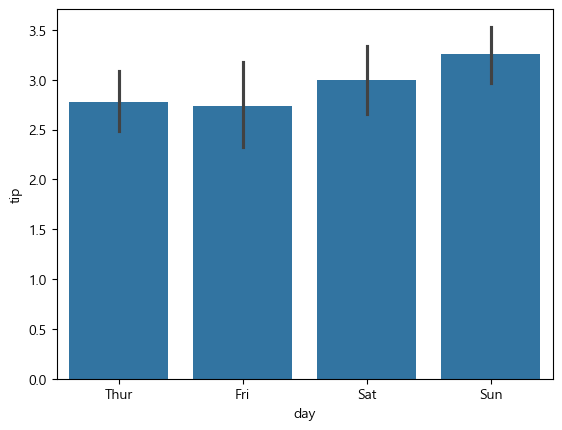

In [7]:
# 범주형(Categorical) — barplot

# 기본 barplot
sns.barplot(data=df_tips, x="day", y="tip") # 요일 별 팁의 평균을 막대 형태로 그리는 것
plt.show()

# errorbar=None이 디폴트
# sns.barplot(data=df_tips, x="day", y="tip", errorbar=None)
# errorbar의 중간이 막대의 높이(평균)
# errorbar의 길이가 길수록 해당 category의 데이터 변동이 크다는 것을 의미

<Axes: xlabel='day', ylabel='tip'>

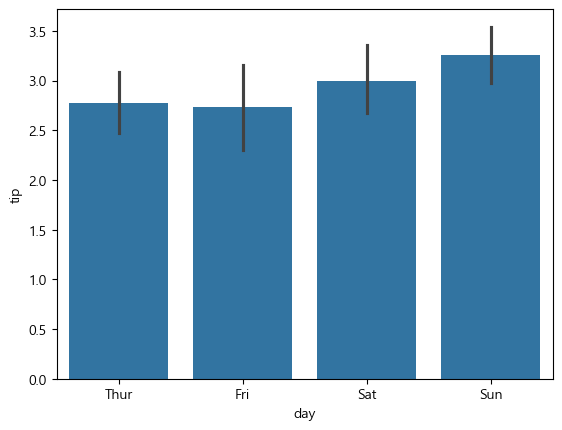

In [8]:

# errorbar=("ci", 95) → 95% 신뢰구간 (기본값)
# 평균값이 95% 확률로 이 범위 안에 있음을 의미
# 확률값이 커지면 에러바의 크기도 커짐
# 막대 높이는 평균이고 실제 데이터는 그 위아래에 존재함
sns.barplot(data=df_tips, x="day", y="tip", errorbar=("ci", 95))
# sns.barplot(data=df_tips, x="day", y="tip", errorbar=("ci", 99))

<Axes: xlabel='day', ylabel='tip'>

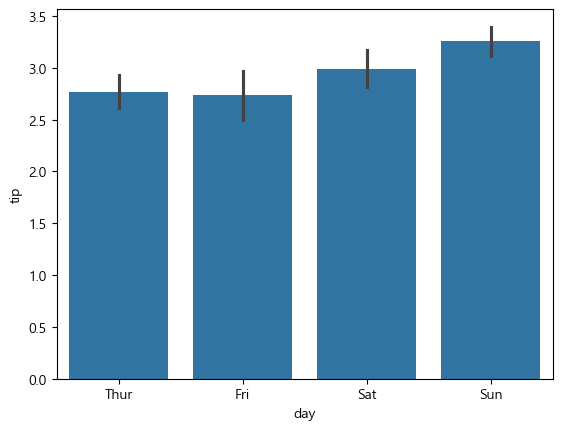

In [9]:
# errorbar=("se", 1) → 표준오차
# 표준오차 = 표준편차 / √n
# 표준편차가 크면 표준오차는 커지고, 데이터 개수가 크면 작아짐 → 평균을 얼마나 믿을 수 있는가?
sns.barplot(data=df_tips, x="day", y="tip", errorbar=("se", 1))

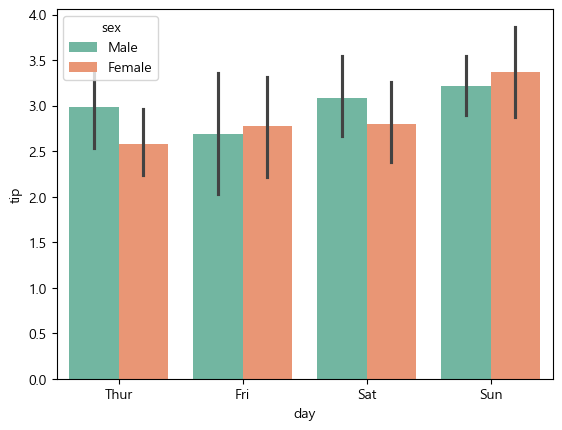

In [10]:
# 범주형(Categorical) — barplot

# hue + palette
sns.barplot(data=df_tips, x="day", y="tip", hue="sex", palette="Set2")
plt.show()

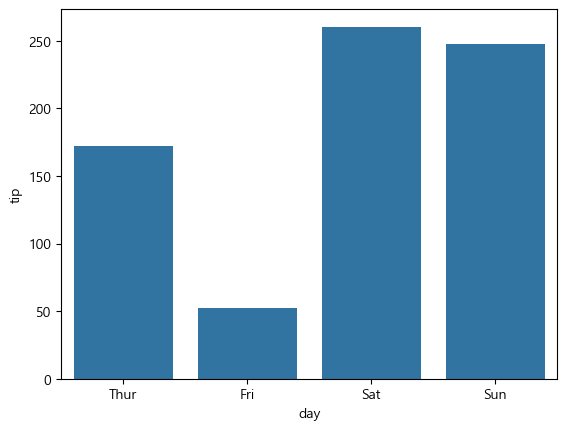

In [11]:
# 범주형(Categorical) — barplot

# estimator + errorbar
# estimator는 막대 높이를 무엇으로 결정할 것인지
# "mean", "sum", "max", "min", "median"
sns.barplot(data=df_tips, x="day", y="tip", estimator="sum", errorbar=None) # errorbar는 sum, max, min의 경우 의미가 없음
plt.show()

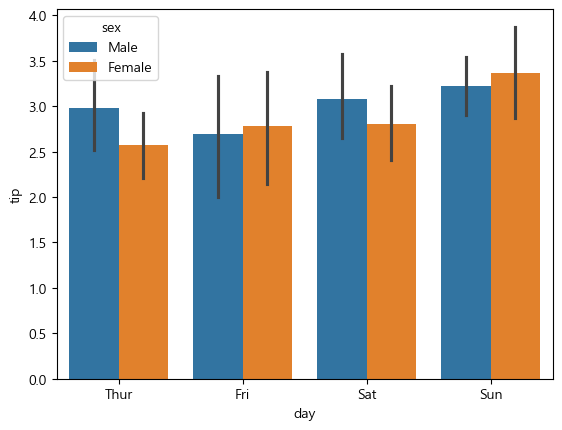

In [12]:
# 범주형(Categorical) — barplot

# order + hue_order
sns.barplot(data=df_tips, x="day", y="tip",
            hue="sex",
            order=["Thur", "Fri", "Sat", "Sun"],    # x축에 표시되는 범주의 순서를 직접 지정/order == 순서
            hue_order=["Male", "Female"])           # 요일 내 순서
            # hue_order=["Female", "Male"])
plt.show()

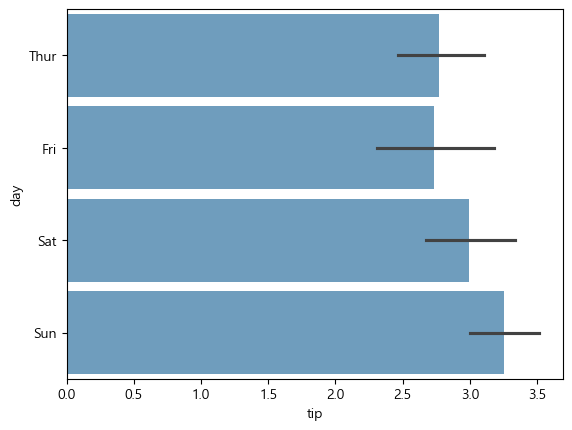

In [13]:
# 범주형(Categorical) — barplot

# orient + width + alpha
sns.barplot(data=df_tips, x="tip", y="day", orient="h", width=0.9, alpha=0.7) # width는 막대의 너비 (요일 방향이며 1이 최대값)
plt.show()

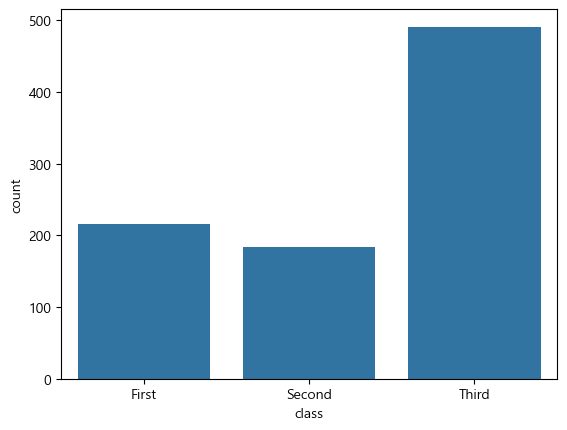

In [14]:
# 범주형(Categorical) — countplot

# 기본 countplot
sns.countplot(data=df_titanic, x="class")
plt.show()

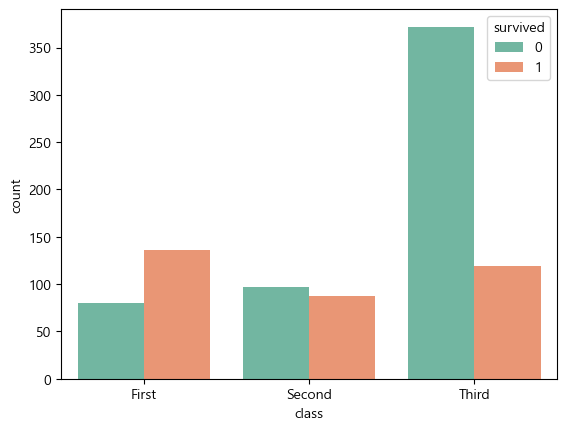

In [15]:
# 범주형(Categorical) — countplot

# hue + palette
sns.countplot(data=df_titanic, x="class", hue="survived", palette="Set2")
plt.show()

<Axes: xlabel='class', ylabel='count'>

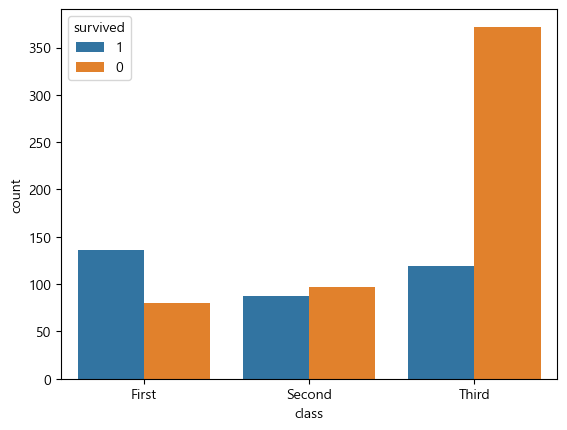

In [16]:
# 범주형(Categorical) — countplot

sns.countplot(data=df_titanic, x="class", hue="survived",
              order=["First", "Second", "Third"],
              hue_order=[1, 0]) # survived 컬럼은 0(사망), 1(생존) 숫자

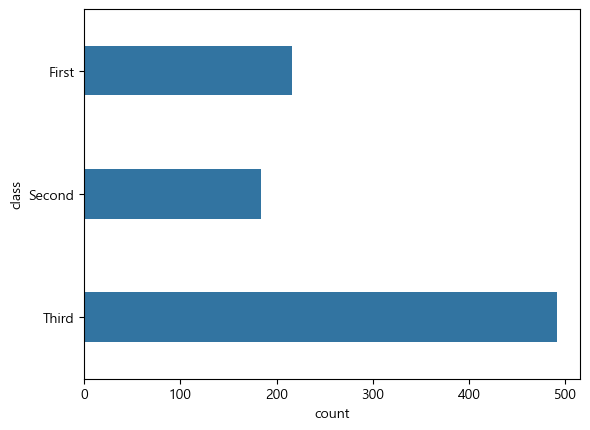

In [17]:
# 범주형(Categorical) — countplot

# orient + width
sns.countplot(data=df_titanic, y="class", orient="h", width=0.4)
plt.show()

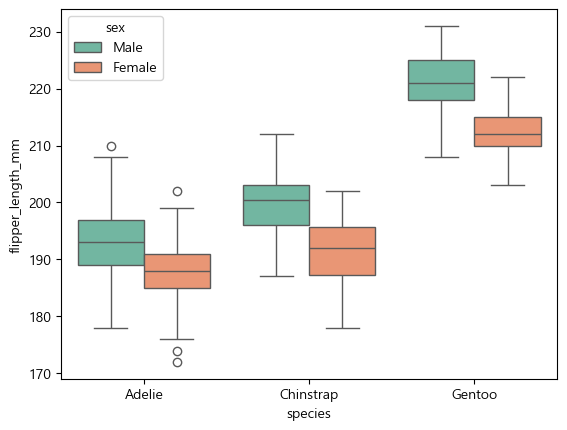

In [18]:
# 범주형(Categorical) — boxplot

# hue + palette
sns.boxplot(data=df_penguins, x="species", y="flipper_length_mm",
            hue="sex", palette="Set2")
plt.show()

# 박스 플롯은 분포를 보여주며 저 동그라미들은 이상치를 표현함

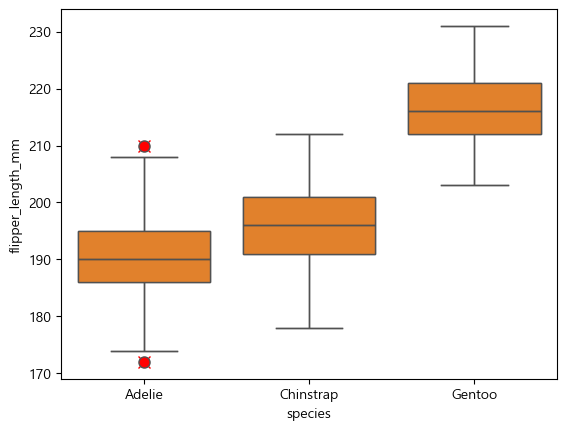

In [19]:
# 범주형(Categorical) — boxplot

# 이상치 마커 스타일
# "x" 마커 → markeredgecolor로 색상 지정
sns.boxplot(data=df_penguins, x="species", y="flipper_length_mm",
            flierprops={"marker": "x", "markeredgecolor": "red", "markersize": 8})

# 채움이 있는 마커 → markerfacecolor 사용 가능
sns.boxplot(data=df_penguins, x="species", y="flipper_length_mm",
            flierprops={"marker": "o", "markerfacecolor": "red", "markersize": 8})

plt.show()

In [20]:
# Q1        하위 25%        데이터의 25%가 이 값보다 작음
# Q2        하위 50%        중앙값, 데이터의 절반이 이 값보다 작음
# Q3        하위 75%        데이터의 75%가 이 값보다 작음
# Q4        100%            최댓값

# 박스플롯에서 박스의 아래가 Q1, 위가 Q3, 중앙선이 Q2

# Tertile       3등분       →  2개의 기준점
# Quartile      4등분       →  3개의 기준점
# Quintile      5등분       →  4개의 기준점
# Percentile    100등분     → 99개의 기준점

# IQR: InterQuartile Range이며 Q1, Q2, Q3를 의미
# IQR(사분위 범위) = Q3 - Q1

# 박스폴롯의 하단 및 상단
# Q1 - 1.5×IQR
# Q3 + 1.5×IQR

# Q1 - 1.5×IQR보다 작거나 Q3 + 1.5×IQR보다 큰 값은 이상치

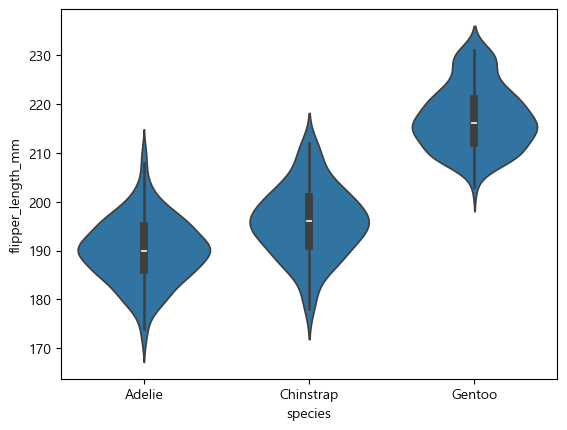

In [21]:
# 범주형(Categorical) — violinplot

# 외부 곡선 → KDE (커널 밀도 추정) 곡선, 데이터가 많이 몰린 곳이 넓어짐
# 내부     → inner 파라미터로 결정(디폴트는 "box")

# "box"         기본, 박스플롯 (Q1, Q2, Q3)
# "quart        "Q1, Q2, Q3 가로선만
# "point        "개별 데이터 점
# "stick"       개별 데이터 세로선
# None          아무것도 표시 안 함

# 기본 violinplot
sns.violinplot(data=df_penguins, x="species", y="flipper_length_mm")
plt.show()

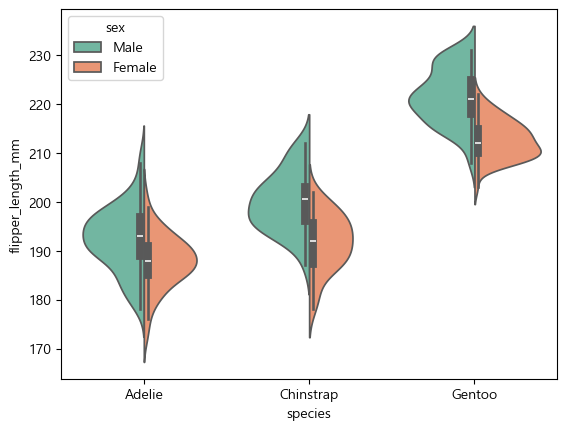

In [22]:
# 범주형(Categorical) — violinplot

# hue + split — hue 2개일 때 좌우로 분리
sns.violinplot(data=df_penguins, x="species", y="flipper_length_mm",
               hue="sex", split=True, palette="Set2")
plt.show()

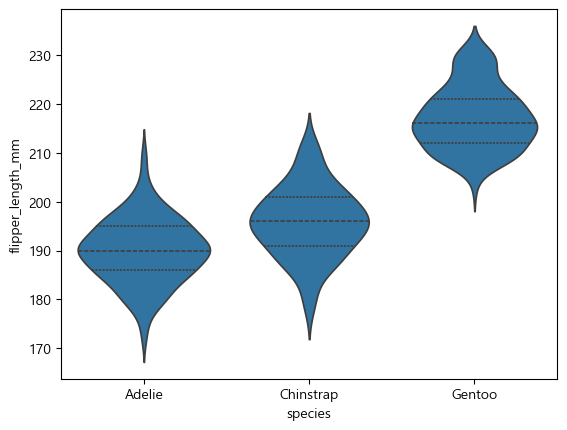

In [23]:
# 범주형(Categorical) — violinplot

# inner — 바이올린 안쪽 표시 방식
# "box" (기본) / "quart" / "point" / "stick" / None
sns.violinplot(data=df_penguins, x="species", y="flipper_length_mm",
               inner="quart")
plt.show()

In [24]:
# stripplot (jitter=True) → 랜덤하게 좌우로 흔들어서 배치 (겹칠 수 있음); random
# swarmplot               → 겹치지 않도록 알고리즘이 좌우로 배치; algorithmic

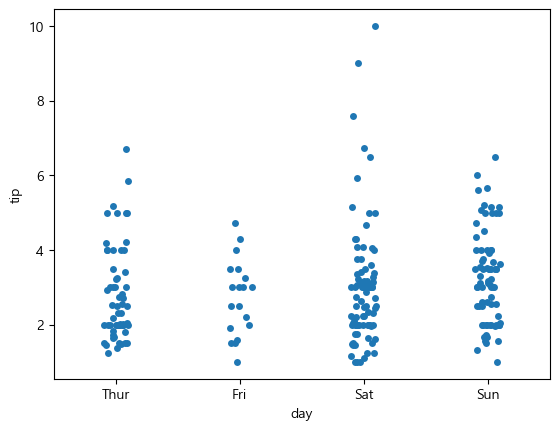

In [25]:
# 범주형(Categorical) — stripplot

# 기본 stripplot
sns.stripplot(data=df_tips, x="day", y="tip")
plt.show()

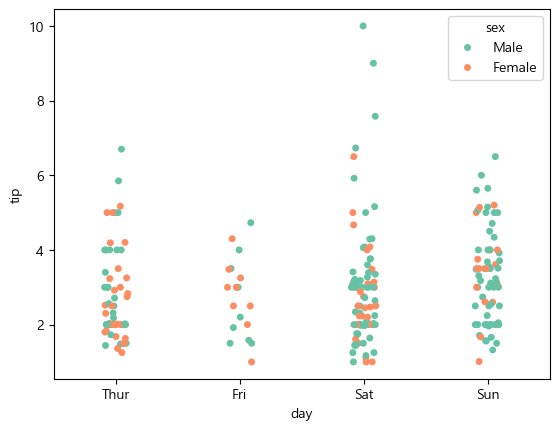

In [26]:
# 범주형(Categorical) — stripplot

# hue + palette
sns.stripplot(data=df_tips, x="day", y="tip", hue="sex", palette="Set2")
plt.show()

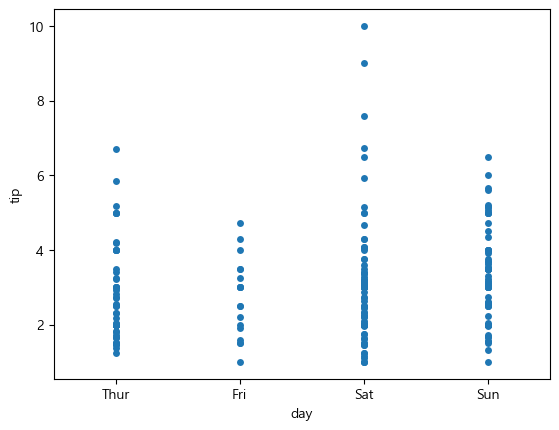

In [27]:
# 범주형(Categorical) — stripplot

# jitter — 점 겹침 방지를 위한 좌우 흔들기
# True (기본) / False / 0.0~1.0 (흔들기 정도)
sns.stripplot(data=df_tips, x="day", y="tip", jitter=False)
# sns.stripplot(data=df_tips, x="day", y="tip", jitter=0.2)
plt.show()

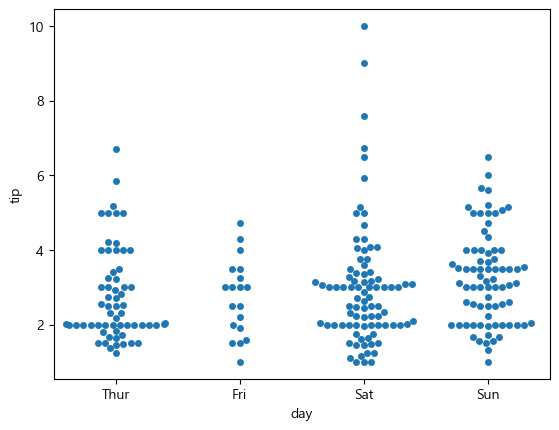

In [28]:
# 범주형(Categorical) — swarmplot

# 기본 swarmplot
sns.swarmplot(data=df_tips, x="day", y="tip") # 얘는 내부 알고리즘에 의해서 알아서 나눠짐
plt.show()

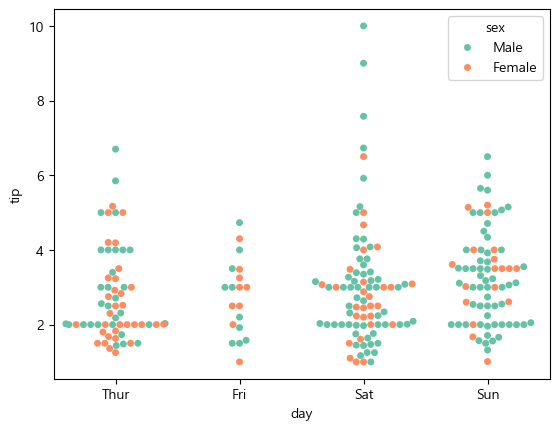

In [29]:
# 범주형(Categorical) — swarmplot

# hue + palette
sns.swarmplot(data=df_tips, x="day", y="tip", hue="sex", palette="Set2")
plt.show()

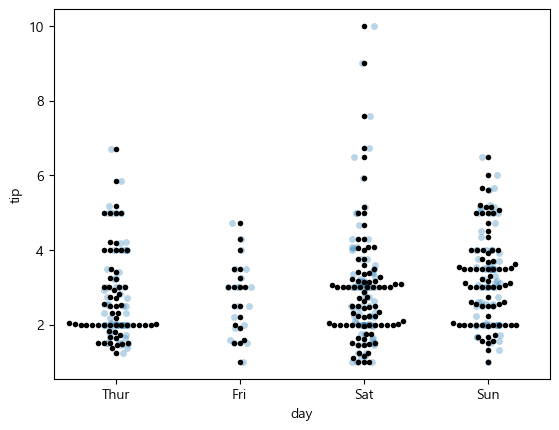

In [30]:
# 범주형(Categorical) — swarmplot

# stripplot + swarmplot 조합
sns.stripplot(data=df_tips, x="day", y="tip", alpha=0.3)
sns.swarmplot(data=df_tips, x="day", y="tip", color="black", size=4)
plt.show()

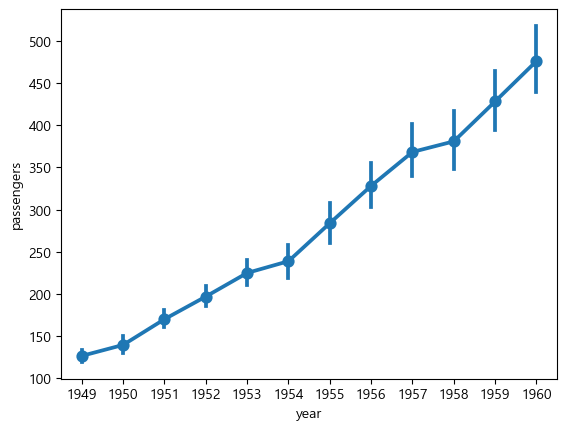

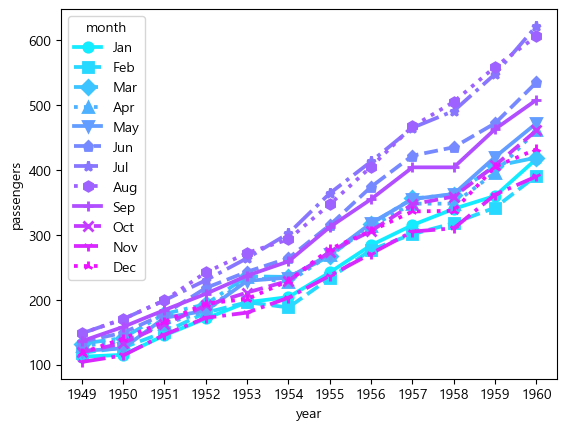

In [31]:
# 범주형(Categorical) — pointplot

# 기본 pointplot
sns.pointplot(data=df_flights, x="year", y="passengers")
plt.show()
 
# %%
# hue + palette + markers + linestyles
sns.pointplot(data=df_flights, x="year", y="passengers",
              hue="month", palette="cool",
              markers=["o", "s", "D", "^", "v", "p", "*", "h", "+", "x", "1", "2"],
              linestyles=["-", "--", "-.", ":", "-", "--", "-.", ":", "-", "--", "-.", ":"])
plt.show()

In [32]:
# catplot은 kind 파라미터로 여러 그래프 유형을 사용

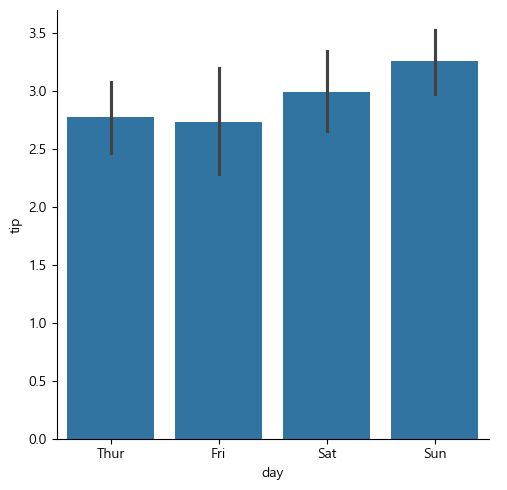

In [33]:
# 범주형(Categorical) — catplot

# 기본 catplot (kind="bar")
sns.catplot(data=df_tips, x="day", y="tip", kind="bar")
plt.show()

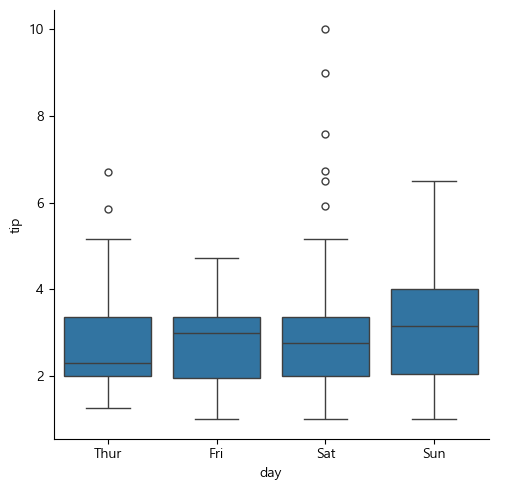

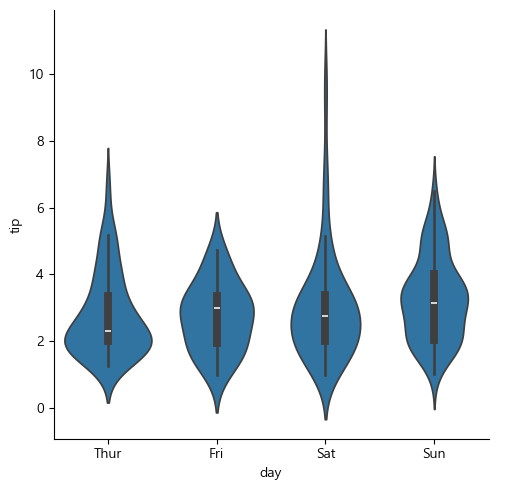

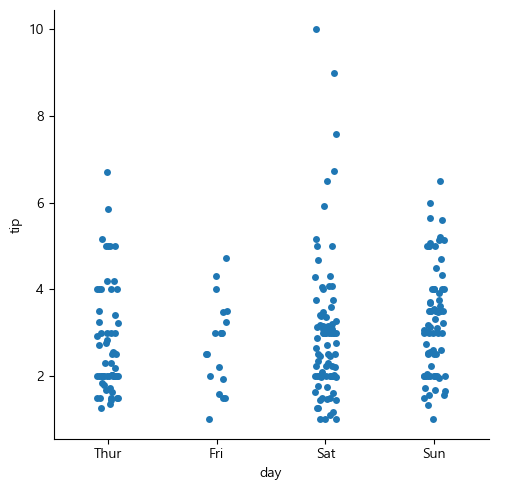

In [34]:
# 범주형(Categorical) — catplot

# kind 변경 — box, violin, strip
sns.catplot(data=df_tips, x="day", y="tip", kind="box")
plt.show()
 
sns.catplot(data=df_tips, x="day", y="tip", kind="violin")
plt.show()
 
sns.catplot(data=df_tips, x="day", y="tip", kind="strip")
plt.show()

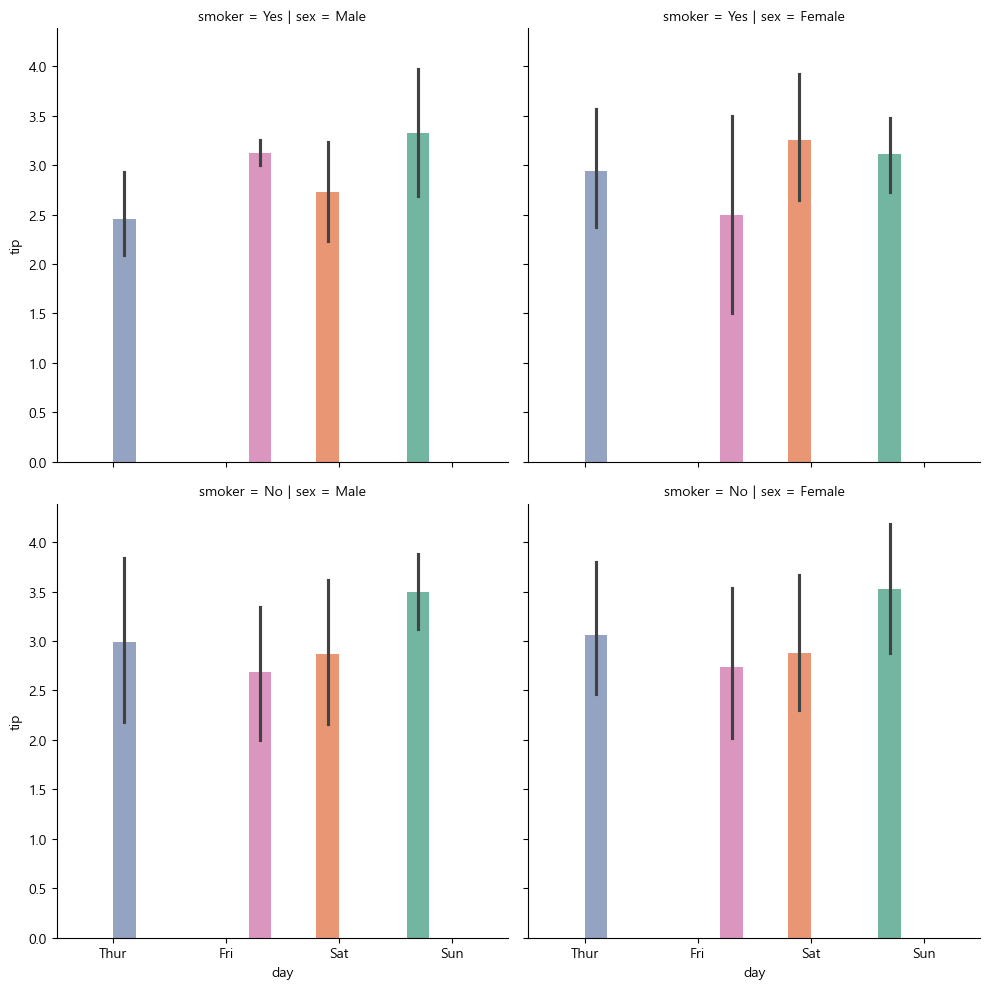

In [35]:
# 범주형(Categorical) — catplot

# col + row 패싯
sns.catplot(data=df_tips, x="day", y="tip", kind="bar", #여기까지는 catplot 유형
            col="sex", row="smoker", hue="day", palette="Set2", legend=False) # 컬럼으로는 성별, 행은 흡연유무, 색은 요일가 팁을 얼마나 줬나 
# 막대기 길이로 신뢰도 파악
plt.show()

In [36]:
# 다변량(Multivariate) — pairplot 숫자인것만 대상으로함
# 수치형 컬럼들의 모든 조합을 격자 형태로 한번에 그려주는 그래프

# 컬럼이 3개 (A, B, C)인 경우 3×3 격자 생성

#      A         B         C
# A [대각선]   [A vs B]  [A vs C]
# B [B vs A]  [대각선]   [B vs C]
# C [C vs A]  [C vs B]  [대각선]

# 대각선(diag_kind): 히스토그램 (diag_kind="hist") or KDE (diag_kind="kde") (각 컬럼의 단변량 분포)
# hue를 사용하면 대각성분은 KDE, hue가 없으면 대각성분은 hist
# 비대각선(kind): 산점도 (두 컬럼 간의 관계)

df_penguins.dtypes


species                  str
island                   str
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                      str
dtype: object

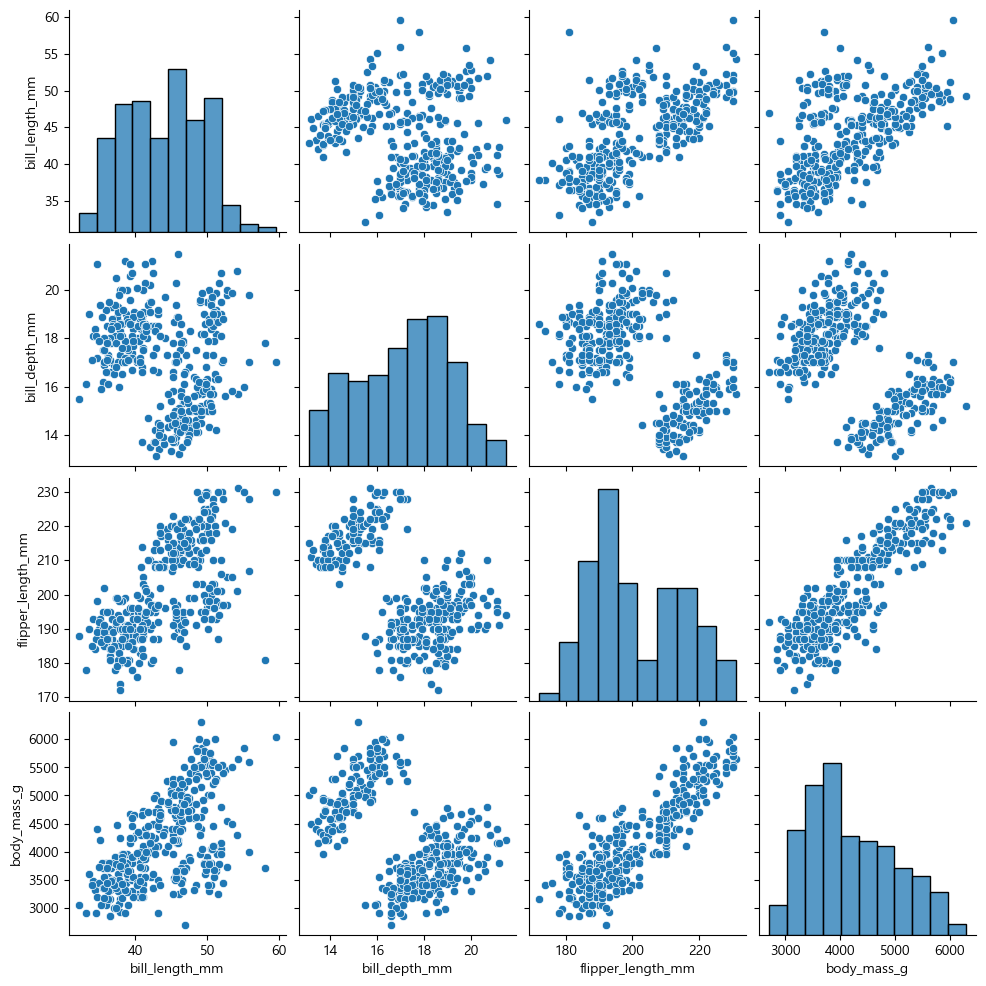

In [37]:

# 기본 pairplot
sns.pairplot(data=df_penguins)
plt.show()

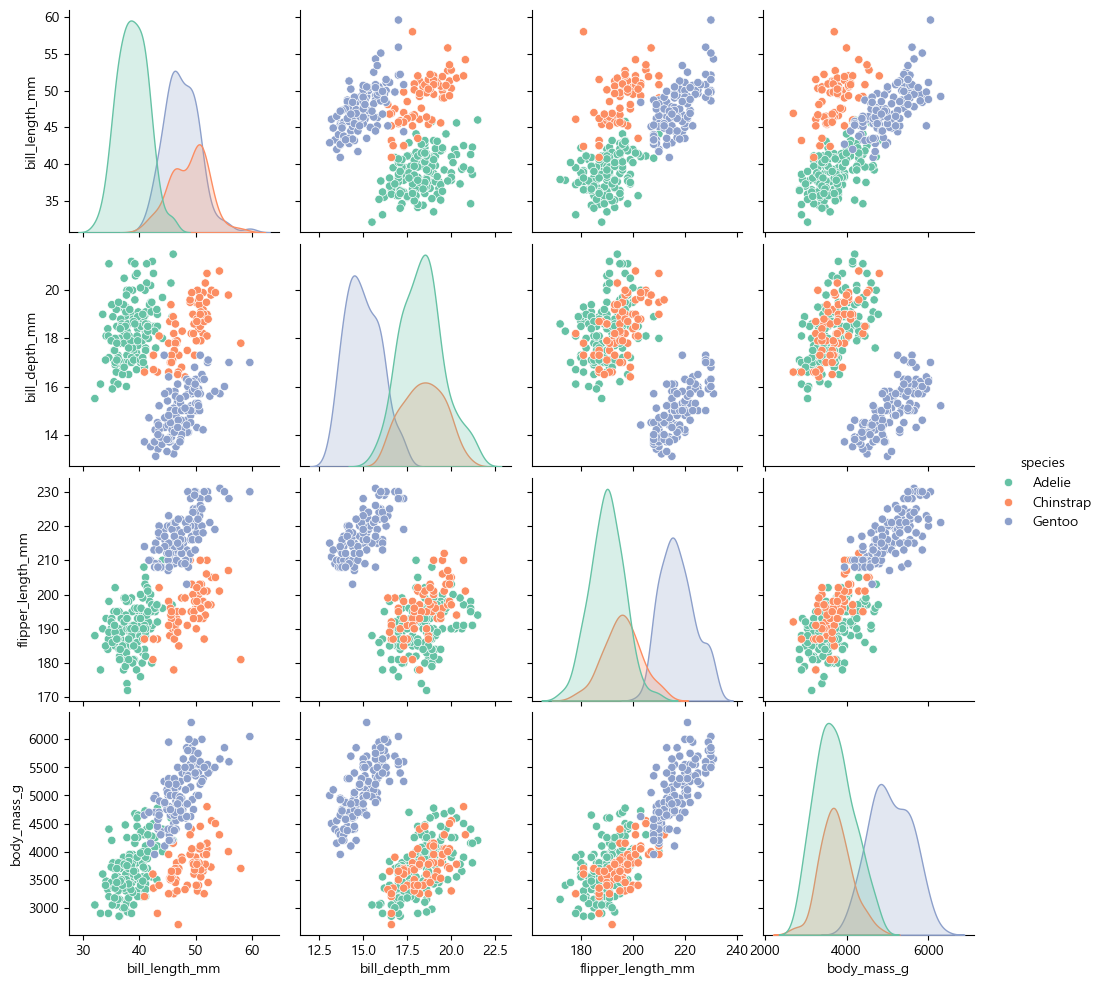

In [38]:
# 다변량(Multivariate) — pairplot

# hue + palette
sns.pairplot(data=df_penguins, hue="species", palette="Set2")
plt.show()

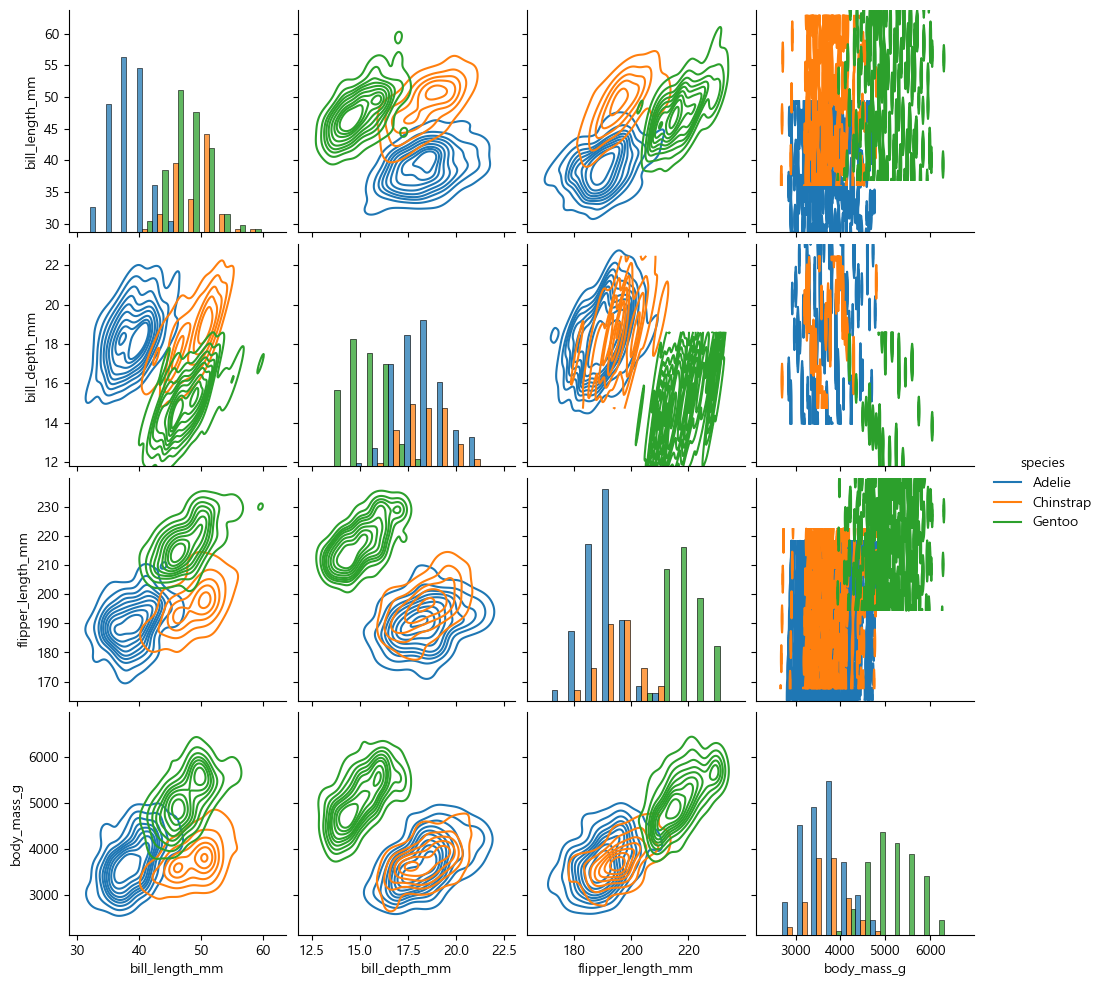

In [ ]:
# 다변량(Multivariate) — pairplot

# kind + diag_kind
# kind: "scatter" (기본) / "kde" / "hist" / "reg"
# diag_kind: "auto" (기본) / "hist" / "kde" / None
sns.pairplot(data=df_penguins, kind="kde", diag_kind="hist", hue="species", diag_kws={"multiple": "dodge"})
plt.show()

# diag_kws는 대각선 그래프에, plot_kws는 비대각선 그래프에 추가 옵션을 전달

# auto -> default값 , none -> 없다는 뜻임 

# 1. diag_kws의 키는

# diag_kind="hist"일 때 → histplot 파라미터: multiple, bins, binwidth, alpha, stat
# "multiple": "layer", "stack", "dodge", "fill"
# bins: 5, 10, 20, 50 (정수)
# binwidth: 0.5, 1.0, 2.0 (실수)
# alpha: 0.0 ~ 1.0 (실수)
# stat: "count", "frequency", "density", "probability"
# 위의 5개의 값을 키워드로 사용할 수 있음

# kde = 복선
# diag_kind="kde"일 때 → kdeplot 파라미터: fill, alpha, linewidth, bw_adjust
# fill: True, False
# alpha: 0.0 ~ 1.0 (실수)
# linewidth: 0.5, 1.0, 2.0 (실수)
# bw_adjust: 0.5 (뾰족), 1.0 (기본), 2.0 (부드러움)


# 2. plot_kws의 키는(나중에 함 해보기)

# kind="scatter"일 때 → scatterplot 파라미터: alpha, s, edgecolor, linewidth
# alpha: 0.0 ~ 1.0 (실수)
# s: 10, 50, 100 (점 크기, 정수)
# edgecolor: "black", "white", "none" (문자열)
# linewidth: 0.5, 1.0, 2.0 (실수)

# kind="kde"일 때 → kdeplot 파라미터: fill, alpha, linewidth, bw_adjust
# fill: True, False
# alpha: 0.0 ~ 1.0 (실수)
# linewidth: 0.5, 1.0, 2.0 (실수)
# bw_adjust: 0.5 (뾰족), 1.0 (기본), 2.0 (부드러움)

# kind="hist"일 때 → histplot 파라미터: bins, alpha, stat
# bins: 5, 10, 20, 50 (정수)
# alpha: 0.0 ~ 1.0 (실수)
# stat: "count", "frequency", "density", "probability"


# kind="kde"의 경우 비대각 성분이 2D KDE
# 등고선이 촘촘할수록 → 그 영역에 데이터가 많이 몰려 있음
# 등고선이 넓을수록  → 데이터가 넓게 퍼져 있음

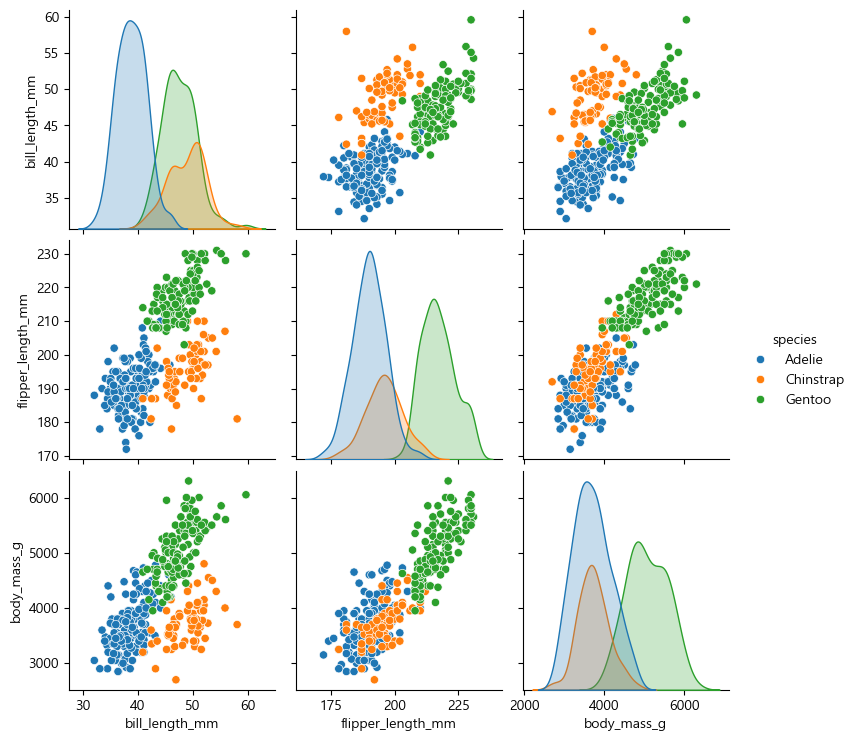

In [40]:
# 다변량(Multivariate) — PairGrid

# vars — 특정 컬럼만 선택
sns.pairplot(data=df_penguins,
             vars=["bill_length_mm", "flipper_length_mm", "body_mass_g"],
             hue="species")
plt.show()